# NB 26 — Pluggable Peer-Network Factory (v0.5)

This notebook demonstrates the new pluggable network factory introduced in
`src/cag/abm/networks.py`. It shows:

1. The five `network_type` options now supported.
2. How to configure each via `network_params`.
3. The shared `compute_diagnostics()` output (always-on cheap metrics +
   conditional clustering / path-length / diameter under a wall-clock cap).
4. A side-by-side visual comparison on a small synthetic agent set, so the
   structural differences (homophily, hubs, small-world clustering, etc.)
   are visible.

No LLM calls are made; this is a pure structural sanity check.


In [1]:
import sys, os, json
from unittest.mock import MagicMock

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from cag.abm.networks import (
    NETWORK_TYPES,
    DEFAULT_HOMOPHILY_ATTRIBUTES,
    build_network,
    compute_diagnostics,
)

print("Available network types:", NETWORK_TYPES)
print("Default homophily attributes:", DEFAULT_HOMOPHILY_ATTRIBUTES)


Available network types: ('stochastic_block', 'erdos_renyi', 'watts_strogatz', 'barabasi_albert', 'homophily_weighted')
Default homophily attributes: ('ukge2019_vote_id', 'brexit_vote_id', 'region_id')


## 1. Synthetic agent set

We build 80 mock agents with two political-exposure groups (40 each) and three
attributes used by the homophily-weighted builder: `ukge2019_vote_id`,
`brexit_vote_id`, `region_id`. The first 40 agents share one attribute profile,
the second 40 share another — so a true homophily model should cluster them.


In [2]:
def make_mock_agents(n=80):
    half = n // 2
    agents = []
    for i in range(n):
        m = MagicMock()
        m.id = f"a{i:03d}"
        m.political_exposure = "A-only" if i < half else "B-only"
        # Cluster A vs cluster B share within-group attribute values.
        m.ukge2019_vote_id = 0 if i < half else 1
        m.brexit_vote_id   = 0 if i < half else 1
        m.region_id        = i % 5  # noise: cuts across exposure
        agents.append(m)
    return agents

agents = make_mock_agents(80)
print(f"{len(agents)} agents, "
      f"{sum(1 for a in agents if a.political_exposure == 'A-only')} A-only / "
      f"{sum(1 for a in agents if a.political_exposure == 'B-only')} B-only")


80 agents, 40 A-only / 40 B-only


## 2. Build all five network types

We use raw parameters for each model (no auto-tuning of density), as agreed
in the design review. The exact knobs are exposed and free to vary per
experiment.


In [5]:
SEED = 7

configs = {
    "stochastic_block":   {"p_intra": 0.20, "p_inter": 0.02},
    "erdos_renyi":        {"p": 0.06},
    "watts_strogatz":     {"k": 6, "beta": 0.10},
    "barabasi_albert":    {"m": 3},
    "homophily_weighted": {
        "attributes": list(DEFAULT_HOMOPHILY_ATTRIBUTES),
        "scale": 8.0,
        "threshold": 8.0,
    },
}

graphs = {
    name: build_network(name, agents, params=params, seed=SEED)
    for name, params in configs.items()
}

for name, G in graphs.items():
    print(f"{name:20s}  n={G.number_of_nodes():3d}  m={G.number_of_edges():4d}")


stochastic_block      n= 80  m= 354
erdos_renyi           n= 80  m= 211
watts_strogatz        n= 80  m= 240
barabasi_albert       n= 80  m= 231
homophily_weighted    n= 80  m= 425


## 3. Diagnostics for each network

Always-on metrics: node/edge count, density, degree summary + histogram,
connected-component summary, assortativity by `political_exposure`.

Conditional metrics (clustering, average shortest path length, diameter)
run under a wall-clock cap (`timeout_s=10` here) plus per-metric size caps,
so this never hangs on a pathological graph.


In [6]:
import pandas as pd

rows = []
for name, G in graphs.items():
    d = compute_diagnostics(G, agents=agents, timeout_s=10)
    rows.append({
        "network_type": name,
        "n_nodes": d["n_nodes"],
        "n_edges": d["n_edges"],
        "density": round(d["density"], 4),
        "mean_degree": round(d["mean_degree"], 2),
        "max_degree": d["max_degree"],
        "components": d["n_connected_components"],
        "largest_cc": d["largest_component_size"],
        "assort_exposure": (
            round(d["assortativity_political_exposure"], 3)
            if d["assortativity_political_exposure"] is not None else None
        ),
        "avg_clustering": round(d.get("average_clustering", float("nan")), 3),
        "avg_path_len":   round(d.get("average_shortest_path_length", float("nan")), 2),
        "diameter":       d.get("diameter", "n/a"),
        "elapsed_s":      d["elapsed_s"],
        "timed_out":      d["timed_out"],
    })

pd.DataFrame(rows).set_index("network_type")


,n_nodes,n_edges,density,mean_degree,max_degree,components,largest_cc,assort_exposure,avg_clustering,avg_path_len,diameter,elapsed_s,timed_out
network_type,,,,,,,,,,,,,
stochastic_block,80,354,0.1120,8.85,15,1,80,0.830,0.200,2.38,4,0.0056,False
erdos_renyi,80,211,0.0668,5.28,11,1,80,-0.024,0.078,2.77,5,0.0041,False
watts_strogatz,80,240,0.0759,6.00,9,1,80,0.808,0.453,3.50,7,0.0044,False
barabasi_albert,80,231,0.0731,5.78,31,1,80,-0.084,0.208,2.47,4,0.0035,False
homophily_weighted,80,425,0.1345,10.62,18,2,40,1.000,0.302,1.74,3,0.0023,False


## 4. Visual side-by-side

Nodes coloured by `political_exposure` (A-only = blue, B-only = orange).
This makes the structural differences obvious — SBM and homophily-weighted
should show two visible communities; ER should look like noise; WS should
show a regular ring with a few rewired shortcuts; BA should show a few
visible hubs.


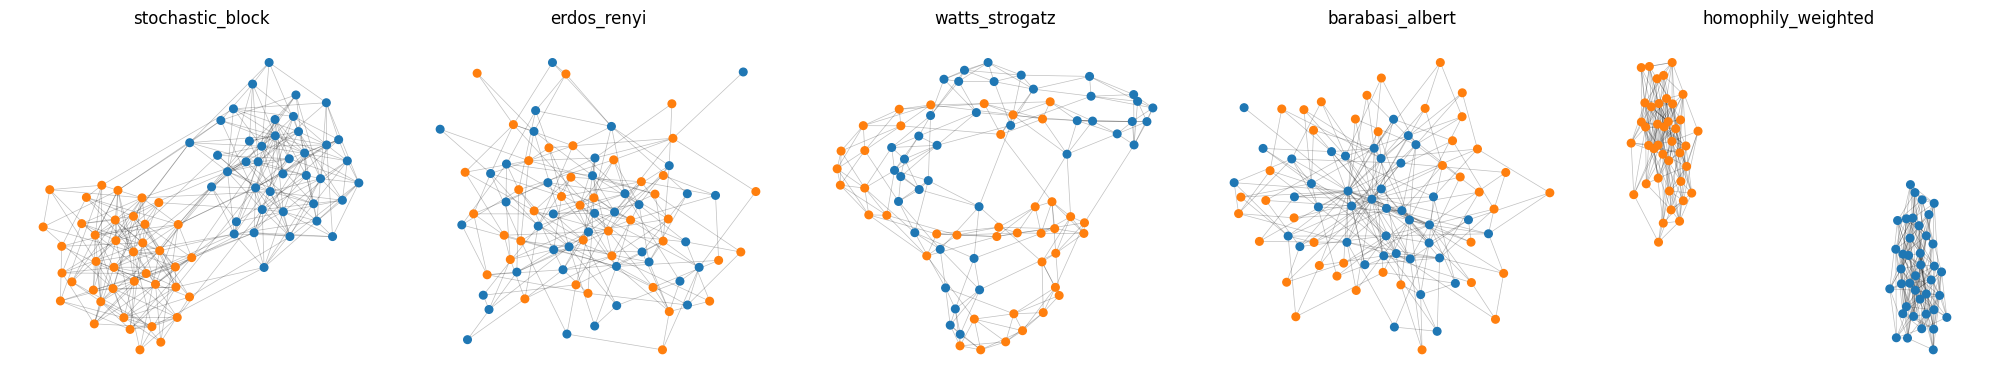

In [7]:
colour_map = {
    a.id: ("#1f77b4" if a.political_exposure == "A-only" else "#ff7f0e")
    for a in agents
}

fig, axes = plt.subplots(1, len(graphs), figsize=(4 * len(graphs), 4))
for ax, (name, G) in zip(axes, graphs.items()):
    pos = nx.spring_layout(G, seed=SEED)
    node_colors = [colour_map[n] for n in G.nodes]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=30, node_color=node_colors)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.5)
    ax.set_title(name)
    ax.set_axis_off()

plt.tight_layout()
plt.show()


## 5. Degree distributions

The qualitative differences in degree distribution are the main reason the
choice of network model matters for opinion dynamics: a hubby network spreads
either side disproportionately, while a homogeneous one does not.


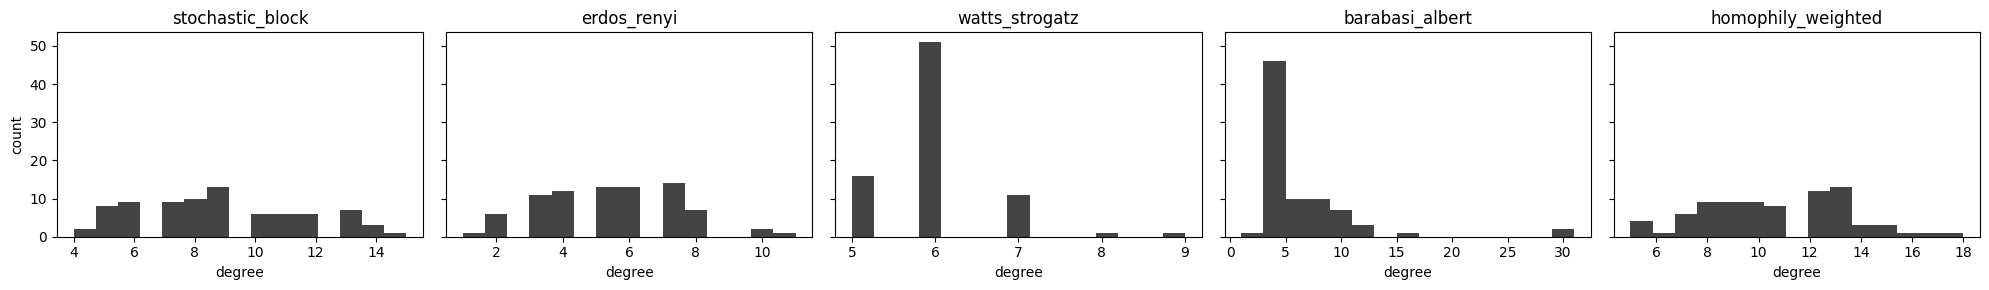

In [8]:
fig, axes = plt.subplots(1, len(graphs), figsize=(4 * len(graphs), 3), sharey=True)
for ax, (name, G) in zip(axes, graphs.items()):
    degs = [d for _, d in G.degree()]
    ax.hist(degs, bins=15, color="#444")
    ax.set_title(name)
    ax.set_xlabel("degree")
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()


## 6. Driving from `SIM_CONFIG`

In real runs the factory is driven from `SIM_CONFIG`. Two new keys:

- `network_type` — one of `NETWORK_TYPES` (default `"stochastic_block"`).
- `network_params` — type-specific dict (defaults are used if `None`).
- `diagnostics_timeout_s` — wall-clock cap (s) on the conditional metrics.

The legacy flat keys `p_intra` / `p_inter` are still honoured for
`stochastic_block`, so existing notebooks/configs keep working unchanged.

Example overrides:

```python
SIM_CONFIG_OVERRIDES = {
    "network_type": "homophily_weighted",
    "network_params": {
        "attributes": ["ukge2019_vote_id", "brexit_vote_id", "region_id"],
        "scale": 8.0,
        "threshold": 4.0,
    },
    "diagnostics_timeout_s": 30.0,
}
```

After a run, structural metrics for the realised graph are written to
`<run_dir>/network_diagnostics.json` so different topologies can be
compared like-for-like in `result_report.md`.
